In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [16]:
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)

In [17]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
scaler = StandardScaler()
x = scaler.fit_transform(df)
print('scaling done')

scaling done


In [47]:
x.shape

(150, 4)

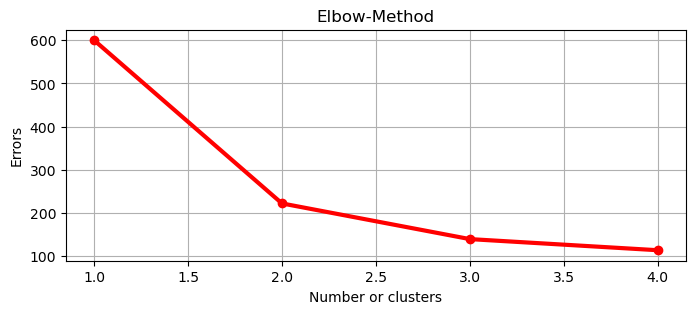

The point where elbow bends is the best value of K


In [49]:
import warnings
warnings.filterwarnings("ignore")
list = []
for k in range(1,5):
    model = KMeans(n_clusters=k, random_state=24,n_init=10)
    model.fit(x)
    list.append(model.inertia_)

plt.figure(figsize=(8,3))
plt.plot(range(1,5),list,marker= 'o',color='red',linewidth='3')
plt.title('Elbow-Method')
plt.xlabel('Number or clusters')
plt.ylabel('Errors')
plt.grid(True)
plt.show()

print('The point where elbow bends is the best value of K')


In [ ]:
km = KMeans(n_clusters=2,random_state=24,n_init=10)
km.fit(x)
df['cluster'] = km.labels_
print('cluster counts:')
print(df["cluster"].value_counts())

cluster counts:
cluster
0    100
1     50
Name: count, dtype: int64


In [44]:
score = silhouette_score(x,km.labels_)
print(f"Silhouette score:{score:.4f}")

Silhouette score:0.5818
